<a href="https://colab.research.google.com/github/TorresZ314/EE344ML_homework/blob/main/344Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    fowlkes_mallows_score,
)


from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, KernelPCA

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Reproducibility
SEED = 42


In [3]:
# Load the dataset
DATA_PATH = "merged_dataset.csv"
df = pd.read_csv(DATA_PATH)
df = df.drop(columns = ['filename'])
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

print("\nSummary statistics:")
display(df.describe(include="all"))

print("\nMissing values per column:")
display(df.isna().sum())


Shape: (603, 64)

Columns:
['x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1', 'x_2', 'y_2', 'z_2', 'x_3', 'y_3', 'z_3', 'x_4', 'y_4', 'z_4', 'x_5', 'y_5', 'z_5', 'x_6', 'y_6', 'z_6', 'x_7', 'y_7', 'z_7', 'x_8', 'y_8', 'z_8', 'x_9', 'y_9', 'z_9', 'x_10', 'y_10', 'z_10', 'x_11', 'y_11', 'z_11', 'x_12', 'y_12', 'z_12', 'x_13', 'y_13', 'z_13', 'x_14', 'y_14', 'z_14', 'x_15', 'y_15', 'z_15', 'x_16', 'y_16', 'z_16', 'x_17', 'y_17', 'z_17', 'x_18', 'y_18', 'z_18', 'x_19', 'y_19', 'z_19', 'x_20', 'y_20', 'z_20', 'direction']


,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,z_2,x_3,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,direction
0,0.646481,0.771554,1.768660e-07,0.683290,0.711169,-0.005896,0.695399,0.647578,-0.021418,0.704892,...,0.645916,0.637718,-0.093269,0.666913,0.669813,-0.083744,0.661707,0.690624,-0.071454,Pointing_Left
1,0.162824,0.676318,-2.872858e-07,0.299672,0.617752,-0.023162,0.377253,0.549926,-0.040260,0.438199,...,0.090932,0.548127,-0.042013,0.114231,0.568613,-0.032944,0.112813,0.586741,-0.029670,Pointing_Right
2,0.863716,0.546938,2.528396e-08,0.810565,0.535083,-0.036838,0.763620,0.547465,-0.063654,0.772106,...,0.904119,0.720734,-0.104208,0.899656,0.659549,-0.097806,0.885778,0.621000,-0.086766,Pointing_Right
3,0.880592,0.755766,-5.697894e-07,0.780115,0.662776,0.026987,0.652597,0.624160,0.015813,0.538131,...,0.510331,0.795934,-0.109579,0.571014,0.808296,-0.105612,0.616264,0.785701,-0.104499,Pointing_Left
4,0.906104,0.576748,-4.809966e-07,0.816000,0.525581,0.001459,0.707359,0.512891,-0.025827,0.608692,...,0.571708,0.608426,-0.114437,0.625317,0.624875,-0.107075,0.668706,0.611069,-0.100873,Pointing_Left



Summary statistics:


,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,z_2,x_3,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,direction
count,603.000000,603.000000,6.030000e+02,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,...,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pointing_Left
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,332
mean,0.715781,0.735929,-3.487243e-07,0.706443,0.683160,0.003729,0.680230,0.634073,-0.004933,0.663679,...,0.600972,0.645125,-0.055950,0.621407,0.658073,-0.046041,0.632897,0.662758,-0.039996,NaN
std,0.225543,0.136449,3.704727e-07,0.144325,0.111320,0.025334,0.103721,0.093750,0.035670,0.115136,...,0.227899,0.137267,0.066078,0.214595,0.136413,0.068018,0.213331,0.131542,0.067879,NaN
min,0.084779,0.349867,-1.604087e-06,0.227501,0.319509,-0.074556,0.324704,0.262256,-0.098541,0.391913,...,-0.019368,0.212147,-0.216320,-0.004502,0.241364,-0.207668,-0.008087,0.261422,-0.207836,NaN
25%,0.637681,0.636364,-5.683308e-07,0.638907,0.619631,-0.014102,0.628731,0.590829,-0.029325,0.597627,...,0.459225,0.577009,-0.107140,0.516716,0.593450,-0.101291,0.551916,0.595459,-0.094182,NaN
50%,0.757556,0.764420,-3.745417e-07,0.724334,0.690265,0.005098,0.690312,0.646569,-0.003555,0.672244,...,0.663837,0.643011,-0.050791,0.684739,0.657576,-0.042030,0.707454,0.677740,-0.036421,NaN
75%,0.870812,0.826535,-5.074367e-08,0.801574,0.759805,0.021948,0.746388,0.690684,0.019525,0.747112,...,0.769731,0.737592,-0.009485,0.770573,0.748555,0.002069,0.772307,0.746388,0.009581,NaN



Missing values per column:


x_0          0
y_0          0
z_0          0
x_1          0
y_1          0
            ..
z_19         0
x_20         0
y_20         0
z_20         0
direction    0
Length: 64, dtype: int64

In [4]:
# Define categorial and numerical columns
CAT_COL = ['direction']
TARGET = 'direction'

# Dynamically select all columns that are not categorical
NUM_COLS = [col for col in df.columns if col not in CAT_COL]
if 'DATA_PATH' in locals():
    df = pd.read_csv(DATA_PATH)
    if 'filename' in df.columns:
        df = df.drop(columns=['filename'])

# Coerce numerical columns to numbers, turning errors into NaNs
df[NUM_COLS] = df[NUM_COLS].apply(pd.to_numeric, errors="coerce")

# Only drop rows where NUMERICAL columns are NaN
# We avoid dropping based on the target column to prevent losing categorical data
df = df.dropna(subset=NUM_COLS).reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("Missing values:\n", df.isna().sum())
print(df[NUM_COLS].shape)

Rows after cleaning: 603
Missing values:
 x_0          0
y_0          0
z_0          0
x_1          0
y_1          0
            ..
z_19         0
x_20         0
y_20         0
z_20         0
direction    0
Length: 64, dtype: int64
(603, 63)


In [5]:
# One hot encoding
# 1. Separate Features and Target
X_raw = df[NUM_COLS]
y_raw = df[[TARGET]]

# 2. Encode the target using OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
y_ohe = ohe.fit_transform(y_raw)
y_ohe = pd.DataFrame(y_ohe, columns=ohe.get_feature_names_out([TARGET]))

print("Target shape after OHE:", y_ohe.shape)
print("Target columns:", y_ohe.columns.tolist())

# 3. Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_ohe, test_size=0.30, random_state=SEED, stratify=y_ohe
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape,  y_test.shape)

display(y_train.head())

Target shape after OHE: (603, 2)
Target columns: ['direction_Pointing_Left', 'direction_Pointing_Right']
Train: (422, 63) (422, 2)
Test : (181, 63) (181, 2)


,direction_Pointing_Left,direction_Pointing_Right
459,0.0,1.0
453,1.0,0.0
348,0.0,1.0
84,1.0,0.0
157,0.0,1.0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

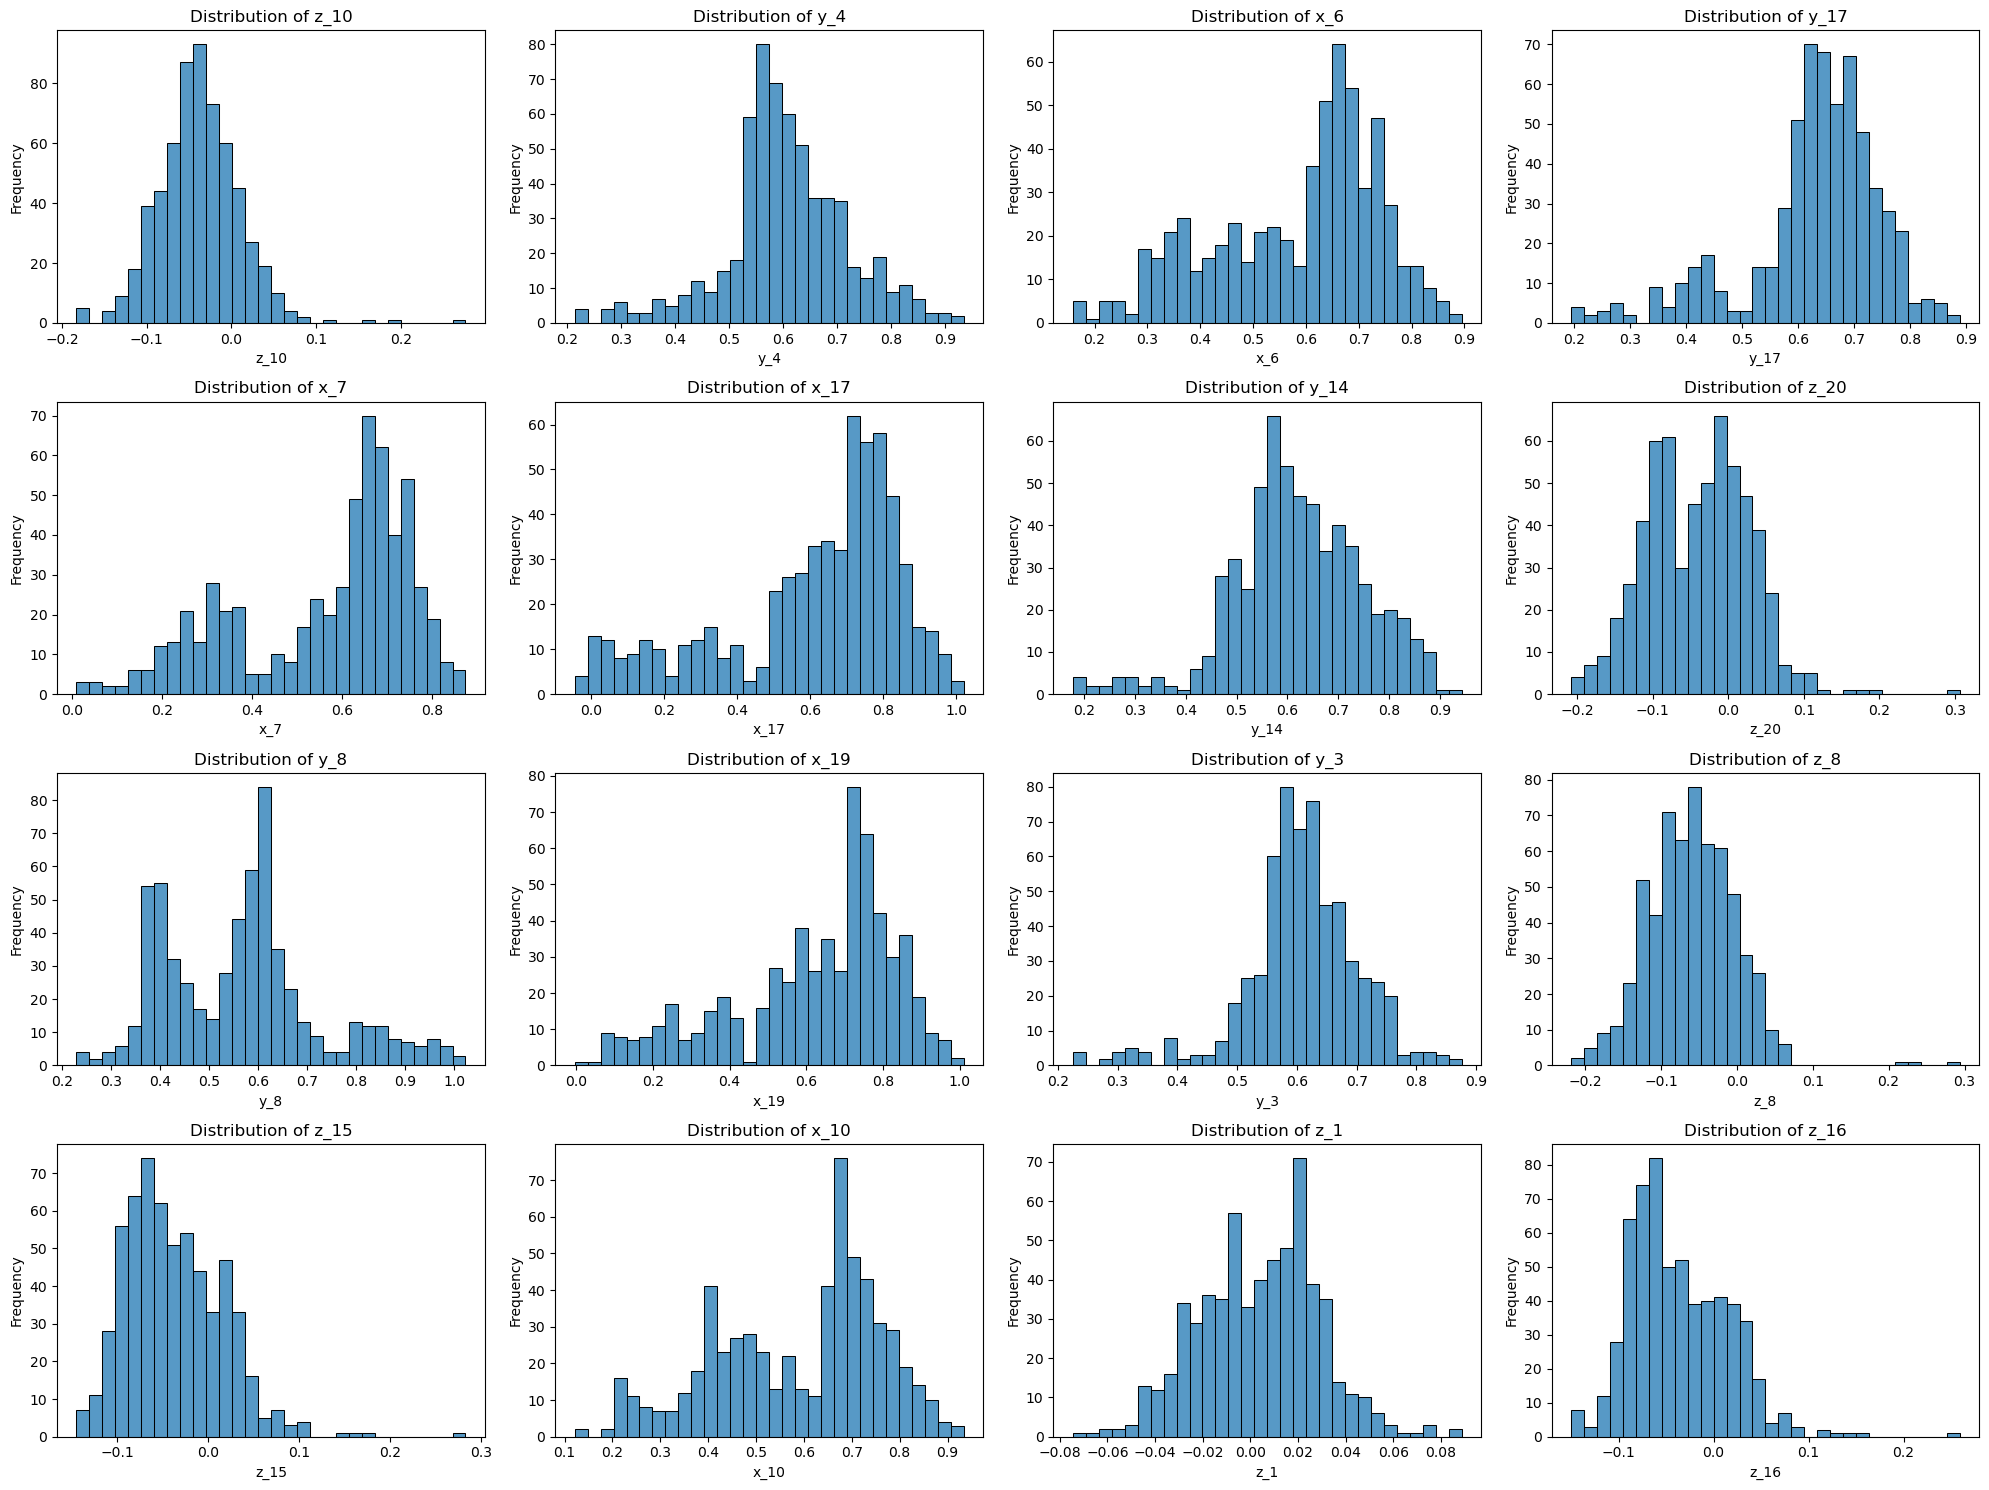

In [6]:

n_features_to_plot = 16

cols_to_plot = random.sample(NUM_COLS, n_features_to_plot)

plt.figure(figsize=(20, 15))
for i, col in enumerate(cols_to_plot):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=False, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
# Scale the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
models = {
    "Logistic Regression": LogisticRegression(solver = "saga", max_iter = 2000, n_jobs = -1, random_state = 42),
    "Perceptron": Perceptron(max_iter=1000, tol=1e-3, random_state=42),
    "SVM (LinearSVC)": LinearSVC(random_state=42),
    "KNN (euclidean)": KNeighborsClassifier(n_neighbors=7, metric="euclidean", n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=40, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Deep Neural Network": MLPClassifier(
      hidden_layer_sizes=(128, 64, 32), # 3 hidden layers
      activation='relu',                # Activation function
      solver='adam',                    # Optimizer
      max_iter=1000,                    # Increased max_iter for convergence
      early_stopping=True,              # Prevents overfitting
      random_state=SEED
    )
}
models.items()

dict_items([('Logistic Regression', LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42, solver='saga')), ('Perceptron', Perceptron(random_state=42)), ('SVM (LinearSVC)', LinearSVC(random_state=42)), ('KNN (euclidean)', KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=7)), ('Decision Tree', DecisionTreeClassifier(max_depth=40, random_state=42)), ('Random Forest', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)), ('Deep Neural Network', MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64, 32),
              max_iter=1000, random_state=42))])

In [9]:
# Helper Method
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def metrics(y_true, y_pred):
    """Return (accuracy, precision, recall, f1)."""
    acc = accuracy_score(y_true, y_pred)

    avg = "binary" if len(np.unique(y_true)) == 2 else "macro"

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=avg, zero_division=0
    )
    return acc, prec, rec, f1

In [10]:
results = []

# Convert OHE targets back to 1D class labels for these models
y_train_labels = np.argmax(y_train.values, axis=1)
y_test_labels = np.argmax(y_test.values, axis=1)

# Baseline Model Evaluation
for model_name, model in models.items():

      model.fit(X_train_scaled, y_train_labels)

      y_train_pred = model.predict(X_train_scaled)
      y_test_pred = model.predict(X_test_scaled)

      acc_train, prec_train, rec_train, f1_train = metrics(y_train_labels, y_train_pred)
      acc_test, prec_test, rec_test, f1_test = metrics(y_test_labels, y_test_pred)

      results.append([model_name, acc_train, prec_train, rec_train, f1_train,
                      acc_test, prec_test, rec_test, f1_test])


cols = [
    "Model",
    "Train Acc", "Train Prec", "Train Rec", "Train F1",
    "Test Acc", "Test Prec", "Test Rec", "Test F1",
]

out = pd.DataFrame(results, columns=cols).sort_values("Test F1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", 80)
print("\n=== Baseline Model Results (sorted by Test F1) ===")
print(out.to_string(index=False, formatters={
    "Train Acc": "{:.4f}".format,
    "Train Prec": "{:.4f}".format,
    "Train Rec": "{:.4f}".format,
    "Train F1": "{:.4f}".format,
    "Test Acc": "{:.4f}".format,
    "Test Prec": "{:.4f}".format,
    "Test Rec": "{:.4f}".format,
    "Test F1": "{:.4f}".format,
}))

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



=== Baseline Model Results (sorted by Test F1) ===
              Model Train Acc Train Prec Train Rec Train F1 Test Acc Test Prec Test Rec Test F1
      Random Forest    1.0000     1.0000    1.0000   1.0000   0.9945    1.0000   0.9877  0.9938
Logistic Regression    0.9976     1.0000    0.9947   0.9974   0.9890    0.9877   0.9877  0.9877
    SVM (LinearSVC)    1.0000     1.0000    1.0000   1.0000   0.9890    0.9877   0.9877  0.9877
    KNN (euclidean)    0.9953     0.9947    0.9947   0.9947   0.9779    0.9753   0.9753  0.9753
         Perceptron    0.9929     0.9895    0.9947   0.9921   0.9669    0.9412   0.9877  0.9639
Deep Neural Network    0.9929     0.9845    1.0000   0.9922   0.9392    0.8889   0.9877  0.9357
      Decision Tree    1.0000     1.0000    1.0000   1.0000   0.9392    0.9070   0.9630  0.9341


In [11]:
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

kpca = KernelPCA(n_components=10, kernel='rbf', random_state=42)
X_kpca = kpca.fit_transform(X_train_scaled)


In [12]:

# predictions after PCA
results = []

for model_name, model in models.items():

      model.fit(X_pca, y_train_labels)

      y_train_pred = model.predict(X_pca)
      y_test_pred = model.predict(X_test_pca)

      acc_train, prec_train, rec_train, f1_train = metrics(y_train_labels, y_train_pred)
      acc_test, prec_test, rec_test, f1_test = metrics(y_test_labels, y_test_pred)

      results.append([model_name, acc_train, prec_train, rec_train, f1_train,
                      acc_test, prec_test, rec_test, f1_test])


cols = [
    "Model",
    "Train Acc", "Train Prec", "Train Rec", "Train F1",
    "Test Acc", "Test Prec", "Test Rec", "Test F1",
]

out = pd.DataFrame(results, columns=cols).sort_values("Test F1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", 80)
print("\n=== PCA Reduced Results (sorted by Test F1) ===")
print(out.to_string(index=False, formatters={
    "Train Acc": "{:.4f}".format,
    "Train Prec": "{:.4f}".format,
    "Train Rec": "{:.4f}".format,
    "Train F1": "{:.4f}".format,
    "Test Acc": "{:.4f}".format,
    "Test Prec": "{:.4f}".format,
    "Test Rec": "{:.4f}".format,
    "Test F1": "{:.4f}".format,
}))

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



=== PCA Reduced Results (sorted by Test F1) ===
              Model Train Acc Train Prec Train Rec Train F1 Test Acc Test Prec Test Rec Test F1
Logistic Regression    0.9976     1.0000    0.9947   0.9974   0.9834    0.9756   0.9877  0.9816
    KNN (euclidean)    0.9953     0.9947    0.9947   0.9947   0.9779    0.9753   0.9753  0.9753
    SVM (LinearSVC)    1.0000     1.0000    1.0000   1.0000   0.9724    0.9524   0.9877  0.9697
         Perceptron    0.9953     0.9947    0.9947   0.9947   0.9669    0.9412   0.9877  0.9639
      Random Forest    1.0000     1.0000    1.0000   1.0000   0.9613    0.9302   0.9877  0.9581
Deep Neural Network    0.9787     0.9892    0.9632   0.9760   0.9503    0.9390   0.9506  0.9448
      Decision Tree    1.0000     1.0000    1.0000   1.0000   0.9227    0.8681   0.9753  0.9186


In [29]:
# t-SNE visualization

def plot_tsne(X, labels, title, perplexity=30):
    X2 = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, (len(X) - 1) // 3)),
        init="pca",
        learning_rate="auto",
        random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(8, 6))
    for lab in sorted(pd.unique(labels)):
        idx = (labels == lab)
        plt.scatter(X2[idx, 0], X2[idx, 1], label=str(lab), alpha=0.7)
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()



Plotting t-SNE on original scaled data...


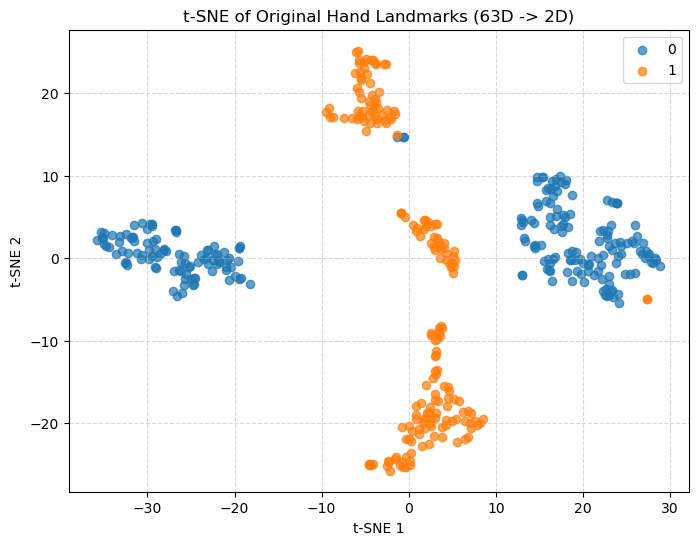

Plotting t-SNE on PCA reduced data...


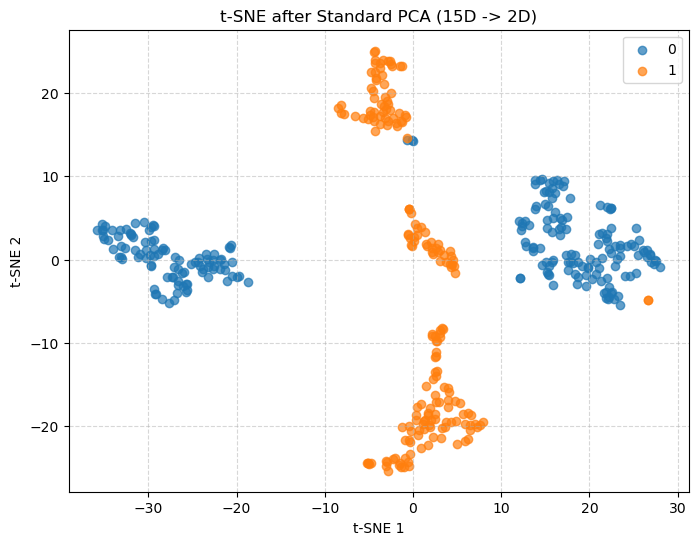

Plotting t-SNE on Kernel PCA reduced data...


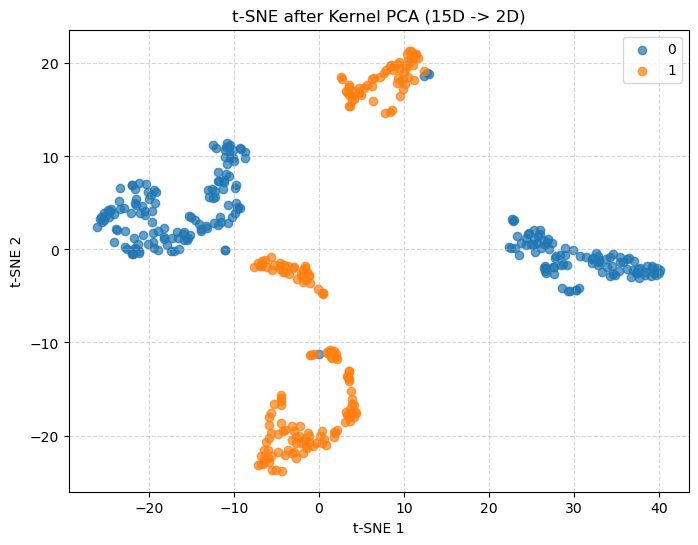

In [30]:
y_labels = np.argmax(y_train.values, axis=1)
print("Plotting t-SNE on original scaled data...")
plot_tsne(X_train_scaled, y_labels, title="t-SNE of Original Hand Landmarks (63D -> 2D)")

print("Plotting t-SNE on PCA reduced data...")
plot_tsne(X_pca, y_labels, title="t-SNE after Standard PCA (15D -> 2D)")

print("Plotting t-SNE on Kernel PCA reduced data...")
plot_tsne(X_kpca, y_labels, title="t-SNE after Kernel PCA (15D -> 2D)")

,k,inertia,silhouette,fowlkes_mallows
0,2,20404.6435,0.2477,0.5113
1,3,16377.5774,0.2746,0.4999
2,4,13270.6630,0.3129,0.5506
3,5,11455.6984,0.3371,0.5718
4,6,10097.7883,0.3094,0.4918
5,7,9179.1725,0.3052,0.4884
6,8,8374.2773,0.3259,0.5140


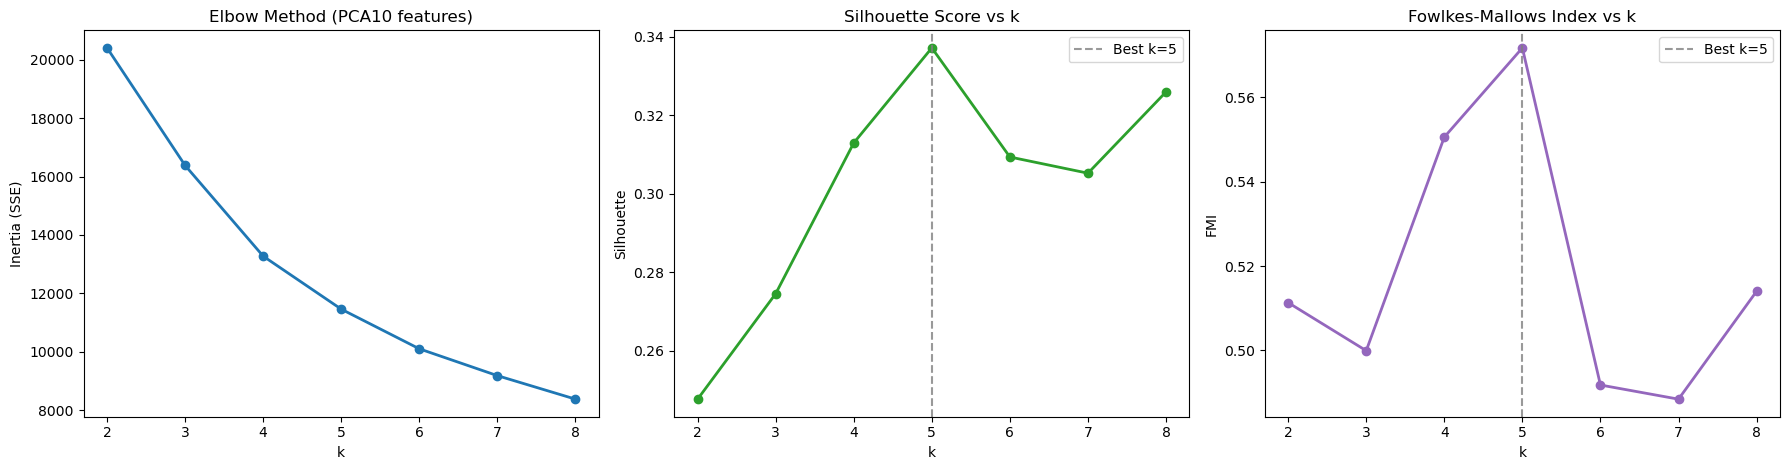

Best k by Silhouette: 5
Best k by FMI       : 5


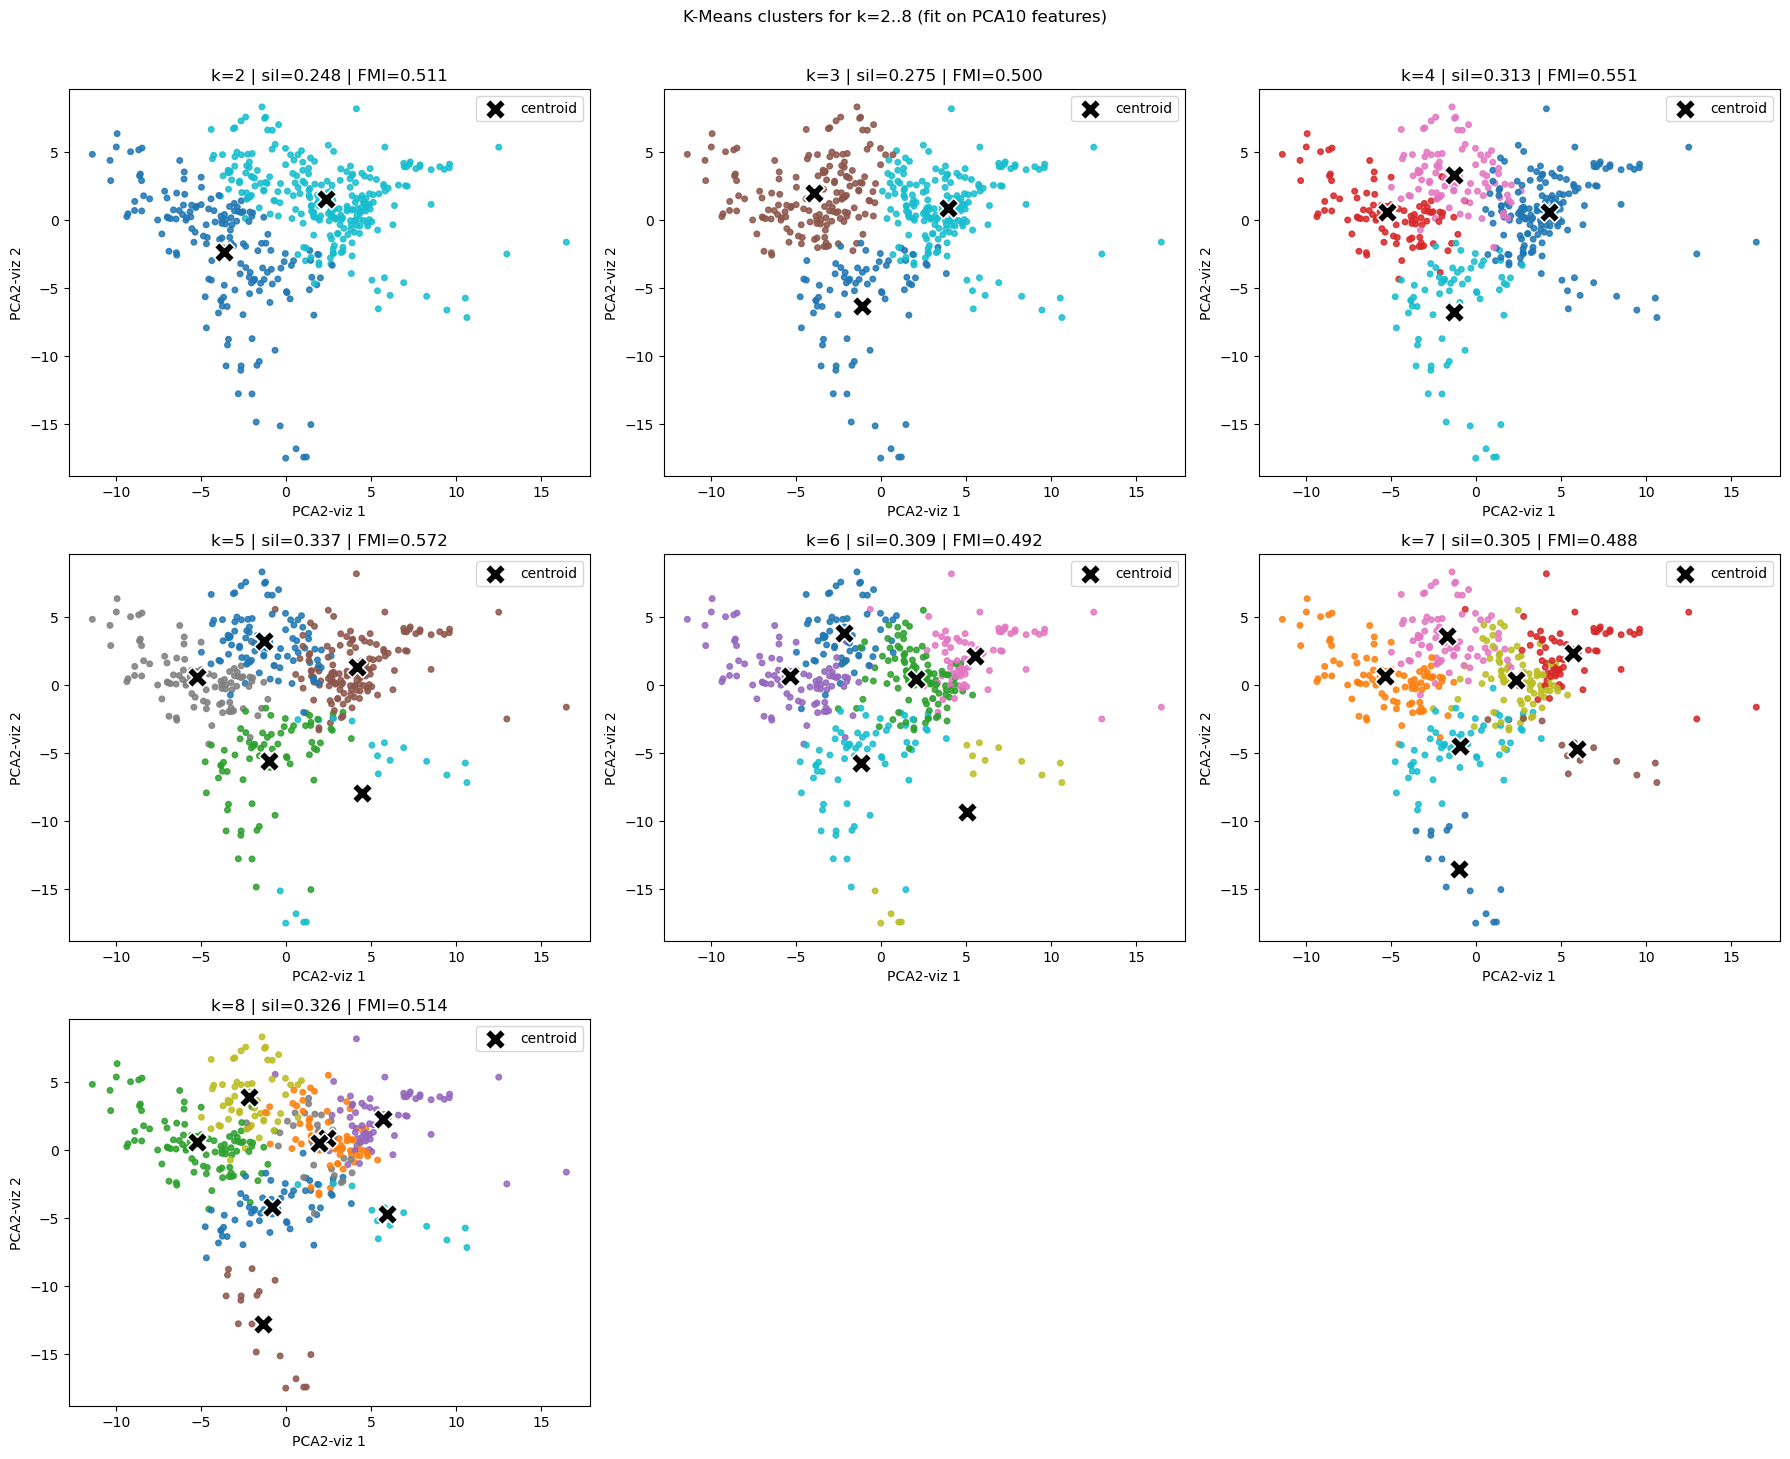

In [ ]:

# -------------------------
# 7) K-Means on PCA(10): k = 2..8
# -------------------------
y_train_labels = np.argmax(y_train.values, axis=1)

K_RANGE = range(2, 9)

rows = []
models_by_k = {}
labels_by_k = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(X_pca)

    models_by_k[k] = km
    labels_by_k[k] = labels

    rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X_pca, labels),
        'fowlkes_mallows': fowlkes_mallows_score(y_train_labels, labels),
    })

km_results = pd.DataFrame(rows)
display(km_results.round(4))

best_k_sil = int(km_results.loc[km_results['silhouette'].idxmax(), 'k'])
best_k_fmi = int(km_results.loc[km_results['fowlkes_mallows'].idxmax(), 'k'])

fig, axs = plt.subplots(1, 3, figsize=(18, 4.8))

# Elbow
axs[0].plot(km_results['k'], km_results['inertia'], marker='o', linewidth=2)
axs[0].set_title('Elbow Method (PCA10 features)')
axs[0].set_xlabel('k')
axs[0].set_ylabel('Inertia (SSE)')

# Silhouette
axs[1].plot(km_results['k'], km_results['silhouette'], marker='o', linewidth=2, color='tab:green')
axs[1].axvline(best_k_sil, linestyle='--', color='gray', alpha=0.8, label=f'Best k={best_k_sil}')
axs[1].set_title('Silhouette Score vs k')
axs[1].set_xlabel('k')
axs[1].set_ylabel('Silhouette')
axs[1].legend(loc='best')

# FMI
axs[2].plot(km_results['k'], km_results['fowlkes_mallows'], marker='o', linewidth=2, color='tab:purple')
axs[2].axvline(best_k_fmi, linestyle='--', color='gray', alpha=0.8, label=f'Best k={best_k_fmi}')
axs[2].set_title('Fowlkes-Mallows Index vs k')
axs[2].set_xlabel('k')
axs[2].set_ylabel('FMI')
axs[2].legend(loc='best')

plt.tight_layout()
plt.show()

print(f'Best k by Silhouette: {best_k_sil}')
print(f'Best k by FMI       : {best_k_fmi}')

# Cluster maps for each k (2D projection for display only)
pca2_viz = PCA(n_components=2, random_state=SEED)
X_2d = pca2_viz.fit_transform(X_pca)

n_k = len(K_RANGE)
n_cols = 3
n_rows = int(np.ceil(n_k / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.8 * n_rows), squeeze=False)

for idx, k in enumerate(K_RANGE):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]

    labels = labels_by_k[k]
    km = models_by_k[k]

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=16, alpha=0.85)

    centers_2d = pca2_viz.transform(km.cluster_centers_)
    ax.scatter(
        centers_2d[:, 0], centers_2d[:, 1],
        marker='X', s=220, c='black', edgecolors='white', linewidths=1.2, label='centroid'
    )

    sil_k = float(km_results.loc[km_results['k'] == k, 'silhouette'].values[0])
    fmi_k = float(km_results.loc[km_results['k'] == k, 'fowlkes_mallows'].values[0])

    ax.set_title(f'k={k} | sil={sil_k:.3f} | FMI={fmi_k:.3f}')
    ax.set_xlabel('PCA2-viz 1')
    ax.set_ylabel('PCA2-viz 2')
    ax.legend(loc='best')

for j in range(n_k, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis('off')

plt.suptitle('K-Means clusters for k=2..7', y=1.01)
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
I0000 00:00:1773287084.973502 5999674 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M1
W0000 00:00:1773287084.978745 5999675 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773287084.990192 5999675 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


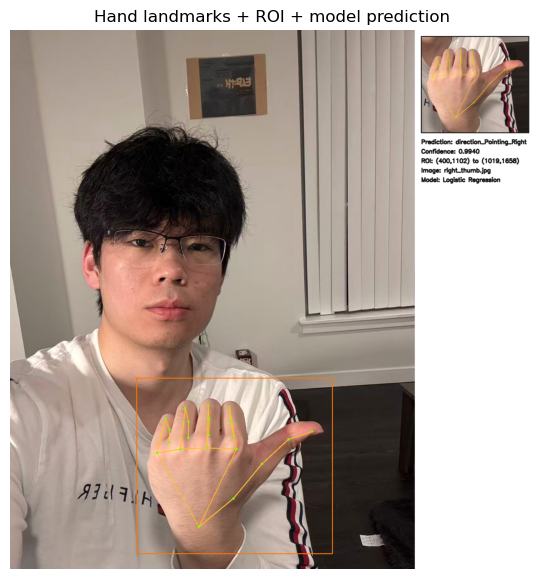

Predicted class: direction_Pointing_Right
Confidence     : 0.9940
Model          : Logistic Regression


In [15]:
# Single-image inference + ROI visualization
# Run all previous cells first (so scaler, models, NUM_COLS, X_train, y_train exist)

from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp

# ---------- User inputs ----------
INPUT_IMAGE = Path('/Users/y/Desktop/344MLhomework/homework/finalProject/right_thumb.jpg')  # <-- change this
LANDMARKER_TASK = Path('/Users/y/Desktop/344MLhomework/homework/finalProject/model/hand_landmarker.task')
NUM_HANDS = 1
PADDING = 0.05  # bbox padding in normalized coords
MODEL_NAME = 'Logistic Regression'  # change to any key in models

# ---------- Checks ----------
required_vars = ['NUM_COLS', 'scaler', 'models', 'X_train', 'y_train']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required variables {missing}. Run notebook cells from top before this inference cell.')

if not INPUT_IMAGE.exists():
    raise FileNotFoundError(f'Input image not found: {INPUT_IMAGE}')
if not LANDMARKER_TASK.exists():
    raise FileNotFoundError(f'Landmarker task not found: {LANDMARKER_TASK}')

# Class name mapping
if 'y_ohe' in globals():
    class_names = list(y_ohe.columns)
elif 'ohe' in globals():
    try:
        class_names = list(ohe.get_feature_names_out([TARGET]))
    except Exception:
        class_names = None
else:
    class_names = None

if not class_names:
    # Fallback to numeric labels
    n_classes = len(np.unique(np.argmax(y_train.values, axis=1)))
    class_names = [str(i) for i in range(n_classes)]

id_to_class = {i: name for i, name in enumerate(class_names)}

# Pick and fit model
if MODEL_NAME not in models:
    raise KeyError(f"MODEL_NAME '{MODEL_NAME}' not in models. Available: {list(models.keys())}")

model = models[MODEL_NAME]

y_train_labels = np.argmax(y_train.values, axis=1)
X_train_scaled_local = X_train_scaled if 'X_train_scaled' in globals() else scaler.transform(X_train)
model.fit(X_train_scaled_local, y_train_labels)

# ---------- Load image ----------
bgr = cv2.imread(str(INPUT_IMAGE))
if bgr is None:
    raise ValueError(f'Could not read image: {INPUT_IMAGE}')

h, w = bgr.shape[:2]
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# ---------- Run MediaPipe Hand Landmarker ----------
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(LANDMARKER_TASK)),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=NUM_HANDS,
)

with HandLandmarker.create_from_options(options) as landmarker:
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)

if not result.hand_landmarks:
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb)
    plt.title('No hand detected')
    plt.axis('off')
    plt.show()
    raise RuntimeError('No hand landmarks detected in the input image.')

# Pick first detected hand
hand_landmarks = result.hand_landmarks[0]
# ---------- Convert landmarks to one-row dataframe ----------
row = {}
for i, lm in enumerate(hand_landmarks):
    row[f'x_{i}'] = float(lm.x)
    row[f'y_{i}'] = float(lm.y)
    row[f'z_{i}'] = float(lm.z)
row_df = pd.DataFrame([row])

# Align to training columns
X_one = row_df.reindex(columns=NUM_COLS, fill_value=0.0)
X_one_scaled = scaler.transform(X_one)

# ---------- Predict ----------
y_pred_id = int(model.predict(X_one_scaled)[0])
y_pred_label = id_to_class.get(y_pred_id, str(y_pred_id))

# Optional confidence estimate
confidence_text = 'N/A'
if hasattr(model, 'predict_proba'):
    p = model.predict_proba(X_one_scaled)[0]
    confidence_text = f'{float(np.max(p)):.4f}'
elif hasattr(model, 'decision_function'):
    d = model.decision_function(X_one_scaled)
    if np.ndim(d) == 1:
        conf = 1.0 / (1.0 + np.exp(-abs(float(d[0]))))
    else:
        conf = float(np.max(d))
    confidence_text = f'{conf:.4f} (margin-based)'

# ---------- Draw landmarks + ROI ----------
annotated = bgr.copy()

# Hand connections (fallback list if API shape differs)
try:
    hand_connections = list(mp.solutions.hands.HAND_CONNECTIONS)
except Exception:
    hand_connections = [
        (0,1),(1,2),(2,3),(3,4),
        (0,5),(5,6),(6,7),(7,8),
        (5,9),(9,10),(10,11),(11,12),
        (9,13),(13,14),(14,15),(15,16),
        (13,17),(17,18),(18,19),(19,20),
        (0,17)
    ]

# Draw connections
for conn in hand_connections:
    s, e = int(conn[0]), int(conn[1])
    x1, y1 = int(hand_landmarks[s].x * w), int(hand_landmarks[s].y * h)
    x2, y2 = int(hand_landmarks[e].x * w), int(hand_landmarks[e].y * h)
    cv2.line(annotated, (x1, y1), (x2, y2), (40, 190, 255), 2)

# Draw landmark points
for i, lm in enumerate(hand_landmarks):
    x, y = int(lm.x * w), int(lm.y * h)
    cv2.circle(annotated, (x, y), 4, (0, 255, 120), -1)

# Compute bounding box (ROI)
xs = np.array([lm.x for lm in hand_landmarks])
ys = np.array([lm.y for lm in hand_landmarks])

x_min = int(max(0, (xs.min() - PADDING) * w))
y_min = int(max(0, (ys.min() - PADDING) * h))
x_max = int(min(w - 1, (xs.max() + PADDING) * w))
y_max = int(min(h - 1, (ys.max() + PADDING) * h))

cv2.rectangle(annotated, (x_min, y_min), (x_max, y_max), (0, 120, 255), 2)

roi = annotated[y_min:y_max+1, x_min:x_max+1]
if roi.size == 0:
    roi = np.ones((120, 120, 3), dtype=np.uint8) * 255

# ---------- Create side panel ----------
panel_w = 380
canvas = np.ones((h, w + panel_w, 3), dtype=np.uint8) * 255
canvas[:, :w] = annotated

# Place ROI preview in side panel
max_roi_w = panel_w - 40
max_roi_h = max(120, int(h * 0.45))
scale = min(max_roi_w / roi.shape[1], max_roi_h / roi.shape[0])
new_w = max(1, int(roi.shape[1] * scale))
new_h = max(1, int(roi.shape[0] * scale))
roi_resized = cv2.resize(roi, (new_w, new_h), interpolation=cv2.INTER_AREA)

x0 = w + 20
y0 = 20
canvas[y0:y0+new_h, x0:x0+new_w] = roi_resized
cv2.rectangle(canvas, (x0, y0), (x0+new_w, y0+new_h), (30, 30, 30), 2)

# Text summary on side panel
text_lines = [
    f'Prediction: {y_pred_label}',
    f'Confidence: {confidence_text}',
    f'ROI: ({x_min},{y_min}) to ({x_max},{y_max})',
    f'Image: {INPUT_IMAGE.name}',
    f'Model: {MODEL_NAME}',
]


ty = y0 + new_h + 35
for line in text_lines:
    cv2.putText(canvas, line, (w + 20, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (20, 20, 20), 2, cv2.LINE_AA)
    ty += 30

# ---------- Display ----------
plt.figure(figsize=(15, 7))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title('Hand landmarks + ROI + model prediction')
plt.axis('off')
plt.show()

print('Predicted class:', y_pred_label)
print('Confidence     :', confidence_text)
print('Model          :', MODEL_NAME)